In [118]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools

from sklearn.metrics import r2_score

def comp_simple_preds(corrections):
    A = np.array([i["absorbance"] for i in corrections])
    f = np.array([i["load"] for i in corrections])
    
    C = A @ A.T
    C = C / np.diag(C)
    
    fhat = (C @ f - f)/(f.shape[0] - 1)
    
    return fhat, r2_score(f, fhat)

import pandas as pd

In [119]:
wn = pd.read_parquet("../data/pfte/SO4/spectra.parquet").columns.astype(float)

with open("../data/spectrabase/ref_dict.pkl", "rb") as f:
    ref_prof = pickle.load(f)
    
gt = ref_prof["Ammonium sulfate"]

loads = pd.read_csv("../data/pfte/lab_loadings.csv",index_col=0,skiprows=4,dtype={"sample": str},)
loads.index = loads.index + ".dpt"

In [120]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_loo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)

In [121]:
for i in range(len(res)):
    id = res[i]["sample_id"]
    
    if id not in loads.index:
        continue
    
    info = loads.loc[id]
    res[i]["analyte"] = info["compounds"]
    
    if info["compounds"] != "Ammonium sulfate":
        res[i]["load"] = info["OC"]

    else:
        res[i]["load"] = info["AS"]
        
    try:
        gt = ref_prof[info["compounds"]]
        a = res[i]["absorbance"]
        res[i]["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    except:
        continue
    
# with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "wb") as f:
#     pickle.dump(res, f)

0.9774868233206254


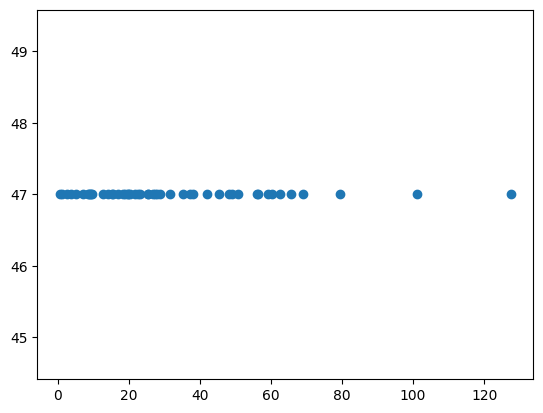

In [122]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "Ammonium sulfate":
        cors.append(res[i]["ref_corr"])
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

0.8680503344684379


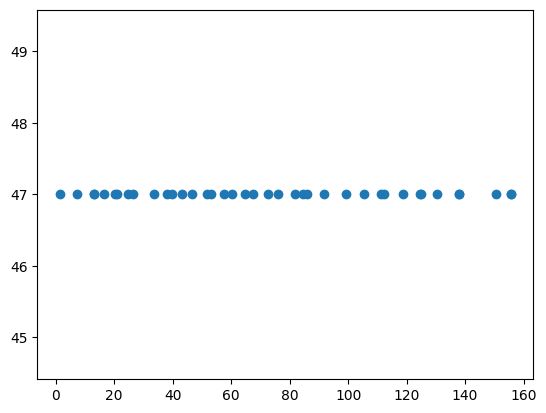

In [123]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "12-Tricosanone":
        cors.append(res[i]["ref_corr"])    
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

0.8145283314698939


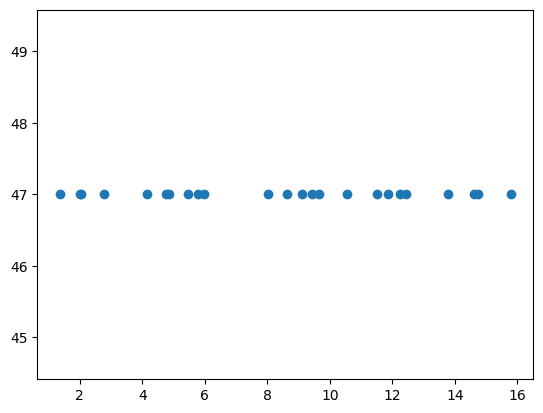

In [125]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "Suberic Acid":
        cors.append(res[i]["ref_corr"])    
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

0.8627910941520446


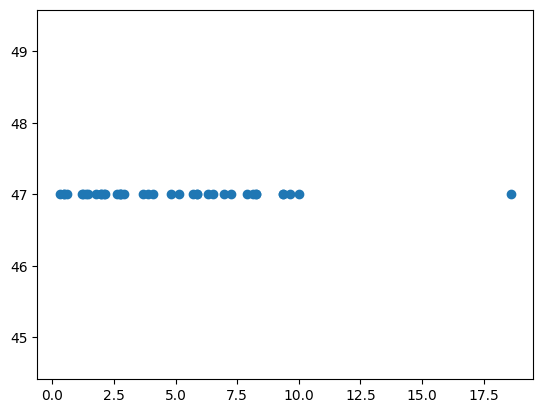

In [126]:
cors = []
chats = []
loads = []

for i in range(len(res)):
    if res[i]["analyte"] == "levoglucosan":
        cors.append(res[i]["ref_corr"])    
        chats.append(res[i]["c"])
        loads.append(res[i]["load"])
        
print(np.mean(cors))
plt.scatter(loads, chats)

In [ ]:
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]

In [89]:
res[0]

{'sample_id': '01033.dpt',
 'absorbance': array([ 2.64029971e-03,  2.39709507e-03,  1.89290221e-03, ...,
         3.86070226e-05,  6.31938885e-06, -2.55723500e-05], shape=(2785,)),
 'time': 5.097945213317871,
 'sigma': np.float64(3.5968595361466864e-05),
 'tau': np.float64(0.030198806401602118),
 'c': np.int64(49),
 'x': array([ 1.35763085e-01, -3.96572420e+00, -2.29201089e+00, -6.20726754e-02,
         1.77907398e+00,  1.16961186e+00,  5.90118247e+00, -5.33995209e+00,
         5.07294075e+00, -2.76522166e+00, -4.85110868e+00,  3.44753493e+00,
        -1.79480009e+00,  1.65487497e+00, -3.18559222e+00, -5.65466598e+00,
        -6.21824706e+00, -7.47071321e+00,  3.49558878e+00, -5.62684854e-01,
        -2.75707582e+00, -4.83034112e+00,  8.93686816e+00,  2.21093259e+00,
         6.14400511e+00,  4.41016769e+00, -4.17591256e+00,  1.32856341e-02,
        -5.14829635e-03, -2.01028407e+00, -1.28560576e+00, -8.89816367e-01,
        -5.59999008e-01,  1.25304478e+00, -5.02866218e-02, -2.08694331

In [79]:
np.unique(loads["compounds"])

array(['1-Docosanol', '1-Docosanol|Adipic Acid',
       '1-Docosanol|Adipic Acid|Suberic Acid', '1-Docosanol|Suberic Acid',
       '12-Tricosanone', 'Ammonium sulfate', 'Arachidyl Dodecanoate',
       'D-Glucose', 'Malonic Acid', 'Suberic Acid', 'fructose',
       'levoglucosan'], dtype=object)

In [86]:
ref_prof['levoglucosan']

array([[3.89724265e+02, 1.09251018e-01],
       [3.95700572e+02, 1.10828262e-01],
       [4.01676879e+02, 1.17193572e-01],
       [4.07653186e+02, 1.23558881e-01],
       [4.13629493e+02, 1.21944083e-01],
       [4.19605801e+02, 1.13945198e-01],
       [4.25582108e+02, 1.15522443e-01],
       [4.31558415e+02, 1.20291731e-01],
       [4.37534722e+02, 1.23464997e-01],
       [4.43511029e+02, 1.29830306e-01],
       [4.49487337e+02, 1.39387659e-01],
       [4.55463644e+02, 1.48945011e-01],
       [4.61439951e+02, 1.63290428e-01],
       [4.67416258e+02, 1.77635844e-01],
       [4.73392565e+02, 1.93577283e-01],
       [4.79368873e+02, 2.27074957e-01],
       [4.85345180e+02, 2.35036288e-01],
       [4.91321487e+02, 2.06289124e-01],
       [4.97297794e+02, 1.72753896e-01],
       [5.03274101e+02, 1.63158991e-01],
       [5.15226716e+02, 1.63121437e-01],
       [5.21203023e+02, 1.63102660e-01],
       [5.27179330e+02, 1.66275927e-01],
       [5.33155637e+02, 1.69449193e-01],
       [5.391319

In [85]:
ref_prof['D-Glucose']

array([[4.04961032e+02, 1.47363620e-02],
       [4.10985499e+02, 2.76534605e-02],
       [4.16821188e+02, 3.44750902e-03],
       ...,
       [3.98017863e+03, 4.66395985e-03],
       [3.98613743e+03, 4.66869312e-03],
       [3.99803863e+03, 1.45006836e-03]], shape=(544, 2))

In [84]:
ref_prof['fructose']

array([[4.63207509e+02, 3.56857667e-01],
       [4.69088680e+02, 3.58454578e-01],
       [4.74969850e+02, 3.63254580e-01],
       [4.80851021e+02, 3.66453036e-01],
       [4.86732192e+02, 3.69651492e-01],
       [4.92613362e+02, 3.72849948e-01],
       [4.98494533e+02, 3.79251496e-01],
       [5.04375703e+02, 3.92059227e-01],
       [5.10256874e+02, 3.93656138e-01],
       [5.16138045e+02, 3.85643773e-01],
       [5.22019215e+02, 3.74428317e-01],
       [5.27900386e+02, 3.72822136e-01],
       [5.33781557e+02, 3.69614409e-01],
       [5.39662727e+02, 3.69609773e-01],
       [5.57306239e+02, 3.69595867e-01],
       [5.63187410e+02, 3.71192777e-01],
       [5.69068580e+02, 3.77594325e-01],
       [5.74949751e+02, 3.85597419e-01],
       [5.80830921e+02, 3.83991238e-01],
       [5.86712092e+02, 3.79181965e-01],
       [5.92593263e+02, 3.79177329e-01],
       [5.98474433e+02, 3.80774240e-01],
       [6.04355604e+02, 3.88777333e-01],
       [6.10236774e+02, 3.88772698e-01],
       [6.161179

In [83]:
ref_prof['Malonic Acid']

array([[3.99632633e+02, 5.02558896e-03],
       [4.05674166e+02, 1.94814564e-02],
       [4.11797898e+02, 4.99941590e-02],
       ...,
       [3.94436063e+03, 7.82669326e-03],
       [3.95032818e+03, 7.83140893e-03],
       [3.95629574e+03, 7.83612459e-03]], shape=(520, 2))

In [82]:
ref_prof['Suberic Acid']

array([[3.98706336e+02, 5.96669312e-02],
       [4.04763340e+02, 4.19636080e-02],
       [4.10789109e+02, 3.04404113e-02],
       ...,
       [3.96752206e+03, 1.37733184e-02],
       [3.97348947e+03, 1.37972002e-02],
       [3.98542430e+03, 1.38449637e-02]], shape=(514, 2))

In [81]:
ref_prof['12-Tricosanone']

array([[4.75273343e+02, 1.07741933e-02],
       [4.81154466e+02, 1.07647997e-02],
       [5.04695163e+02, 1.39726985e-02],
       [5.10584387e+02, 1.55860414e-02],
       [5.16473611e+02, 1.71993844e-02],
       [5.51760354e+02, 1.71430231e-02],
       [5.57641477e+02, 1.71336295e-02],
       [5.63522601e+02, 1.71242359e-02],
       [5.75301050e+02, 2.03509218e-02],
       [5.81182174e+02, 2.03415283e-02],
       [5.87063297e+02, 2.03321347e-02],
       [5.92928220e+02, 1.70772682e-02],
       [5.98809343e+02, 1.70678746e-02],
       [6.04690467e+02, 1.70584811e-02],
       [6.34096086e+02, 1.70115133e-02],
       [6.39977209e+02, 1.70021197e-02],
       [6.69382828e+02, 1.69551520e-02],
       [6.75263952e+02, 1.69457584e-02],
       [6.87042401e+02, 2.01724443e-02],
       [6.92931625e+02, 2.17857873e-02],
       [6.98837051e+02, 2.66446032e-02],
       [7.04823484e+02, 4.77307842e-02],
       [7.11437723e+02, 1.94579044e-01],
       [7.17318847e+02, 1.94569650e-01],
       [7.231351

In [80]:
ref_prof["Ammonium sulfate"]

array([[5.90000000e+02, 4.11161657e-03],
       [5.92000000e+02, 5.19834544e-03],
       [5.94000000e+02, 8.63030508e-03],
       ...,
       [3.99400000e+03, 1.14930890e-05],
       [3.99600000e+03, 8.53555458e-06],
       [3.99800000e+03, 1.74804192e-05]], shape=(1705, 2))

In [ ]:
info

{'CO2': array([[4.19127000e+02, 3.08920092e-10],
        [4.20413000e+02, 3.61852635e-10],
        [4.21699000e+02, 3.54775280e-10],
        ...,
        [3.99585200e+03, 1.42699595e-08],
        [3.99713800e+03, 1.33072754e-08],
        [3.99842300e+03, 1.12694056e-08]], shape=(2785, 2)),
 '12-Tricosanone': array([[4.75273343e+02, 1.07741933e-02],
        [4.81154466e+02, 1.07647997e-02],
        [5.04695163e+02, 1.39726985e-02],
        [5.10584387e+02, 1.55860414e-02],
        [5.16473611e+02, 1.71993844e-02],
        [5.51760354e+02, 1.71430231e-02],
        [5.57641477e+02, 1.71336295e-02],
        [5.63522601e+02, 1.71242359e-02],
        [5.75301050e+02, 2.03509218e-02],
        [5.81182174e+02, 2.03415283e-02],
        [5.87063297e+02, 2.03321347e-02],
        [5.92928220e+02, 1.70772682e-02],
        [5.98809343e+02, 1.70678746e-02],
        [6.04690467e+02, 1.70584811e-02],
        [6.34096086e+02, 1.70115133e-02],
        [6.39977209e+02, 1.70021197e-02],
        [6.69382828

In [75]:
res[i]

{'sample_id': '01033.dpt',
 'absorbance': array([ 2.64029971e-03,  2.39709507e-03,  1.89290221e-03, ...,
         3.86070226e-05,  6.31938885e-06, -2.55723500e-05], shape=(2785,)),
 'time': 5.097945213317871,
 'sigma': np.float64(3.5968595361466864e-05),
 'tau': np.float64(0.030198806401602118),
 'c': np.int64(49),
 'x': array([ 1.35763085e-01, -3.96572420e+00, -2.29201089e+00, -6.20726754e-02,
         1.77907398e+00,  1.16961186e+00,  5.90118247e+00, -5.33995209e+00,
         5.07294075e+00, -2.76522166e+00, -4.85110868e+00,  3.44753493e+00,
        -1.79480009e+00,  1.65487497e+00, -3.18559222e+00, -5.65466598e+00,
        -6.21824706e+00, -7.47071321e+00,  3.49558878e+00, -5.62684854e-01,
        -2.75707582e+00, -4.83034112e+00,  8.93686816e+00,  2.21093259e+00,
         6.14400511e+00,  4.41016769e+00, -4.17591256e+00,  1.32856341e-02,
        -5.14829635e-03, -2.01028407e+00, -1.28560576e+00, -8.89816367e-01,
        -5.59999008e-01,  1.25304478e+00, -5.02866218e-02, -2.08694331

In [69]:
ref_prof

{'CO2': array([[4.19127000e+02, 3.08920092e-10],
        [4.20413000e+02, 3.61852635e-10],
        [4.21699000e+02, 3.54775280e-10],
        ...,
        [3.99585200e+03, 1.42699595e-08],
        [3.99713800e+03, 1.33072754e-08],
        [3.99842300e+03, 1.12694056e-08]], shape=(2785, 2)),
 '12-Tricosanone': array([[4.75273343e+02, 1.07741933e-02],
        [4.81154466e+02, 1.07647997e-02],
        [5.04695163e+02, 1.39726985e-02],
        [5.10584387e+02, 1.55860414e-02],
        [5.16473611e+02, 1.71993844e-02],
        [5.51760354e+02, 1.71430231e-02],
        [5.57641477e+02, 1.71336295e-02],
        [5.63522601e+02, 1.71242359e-02],
        [5.75301050e+02, 2.03509218e-02],
        [5.81182174e+02, 2.03415283e-02],
        [5.87063297e+02, 2.03321347e-02],
        [5.92928220e+02, 1.70772682e-02],
        [5.98809343e+02, 1.70678746e-02],
        [6.04690467e+02, 1.70584811e-02],
        [6.34096086e+02, 1.70115133e-02],
        [6.39977209e+02, 1.70021197e-02],
        [6.69382828

compounds    1-Docosanol
TRset        calibration
AS                   0.0
OC              5.758121
cCOH                 0.0
CO                   0.0
aCH             0.980681
aCOH            0.021793
Name: 01033.dpt, dtype: object

### MAP - ALS

In [7]:
with open(f"../data/corrections/teflon/map/als/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [28]:
with open(f"../data/pfte/lab_samples/map/ALS_c_loo_tau_0.1.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

93.58823702446904
93.58823702446904


In [33]:
with open(f"../data/pfte/lab_samples/map/ALS_c_loo_tau_bcv.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

93.14562123512209
93.14562123512209


In [34]:
with open(f"../data/pfte/lab_samples/map/ALS_c_bcv_tau_0.1.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))

91.34786190486362


In [35]:
with open(f"../data/pfte/lab_samples/map/ALS_c_bcv_tau_bcv.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))

90.08671768418667


### MAP - PB

In [36]:
with open(f"../data/corrections/teflon/map/pb/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [37]:
with open(f"../data/pfte/lab_samples/map/PB_c_loo_tau_0.1.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

96.01214212314153
96.01214212313997


In [38]:
with open(f"../data/pfte/lab_samples/map/PB_c_loo_tau_bcv.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

96.57452233080316
96.57452233080338


In [ ]:
bb

### EBS - ALS

In [33]:
with open(f"../data/corrections/teflon/ebs/als/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [37]:
with open(f"../data/teflon/SO4/ebs/ALS_c_loo_tau_0.1.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["fixed"]["Ammonium sulfate"]["mean"])

63.49006380681885
63.49006380681883


In [38]:
with open(f"../data/teflon/SO4/ebs/ALS_c_loo_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["tau"]["Ammonium sulfate"]["mean"])

67.96332383263002
67.96332383262997


In [39]:
with open(f"../data/teflon/SO4/ebs/ALS_c_bcv_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["c_tau"]["Ammonium sulfate"]["mean"])

91.2752207645272
85.42056511339155


### EBS - PB

In [44]:
with open(f"../data/corrections/teflon/ebs/pb/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [45]:
with open(f"../data/teflon/SO4/ebs/PB_c_loo_tau_0.1.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["fixed"]["Ammonium sulfate"]["mean"])

81.2519041371399
81.25190413714046


In [46]:
with open(f"../data/teflon/SO4/ebs/PB_c_loo_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["tau"]["Ammonium sulfate"]["mean"])

90.83691716652694
90.83691716652083


In [47]:
with open(f"../data/teflon/SO4/ebs/PB_c_bcv_tau_bcv.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["c_tau"]["Ammonium sulfate"]["mean"])

83.94839615853759
83.94839615853816


### VIBES - ALS

In [18]:
with open(f"../data/corrections/teflon/veb/als/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [19]:
with open(f"../data/teflon/SO4/vibes/ALS_c_loo_tau_0.1_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

95.64337479814344
95.64337479814344


In [20]:
with open(f"../data/teflon/SO4/vibes/ALS_c_loo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

96.75152722634233
96.75152722634235


In [21]:
with open(f"../data/teflon/SO4/vibes/ALS_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau_c"]["Ammonium sulfate"]["mean"])

96.72707000748024
96.71174442627968


### VIBES - PB

In [45]:
with open(f"../data/corrections/teflon/veb/pb/corr_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)


In [23]:
with open(f"../data/teflon/SO4/vibes/PB_c_loo_tau_0.1_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
      
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma"]["Ammonium sulfate"]["mean"])

97.7879202700439
97.78792027004391


In [24]:
with open(f"../data/teflon/SO4/vibes/PB_c_loo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau"]["Ammonium sulfate"]["mean"])

97.74868233206254
97.74868233206253


In [42]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)
    
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau_c"]["Ammonium sulfate"]["mean"])

32.06838081879964


KeyError: 'sigma_tau_c'

In [47]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res_all = pickle.load(f)
    
res = []

for i in range(len(res_all)):
    if loads.loc[res_all[i]["sample_id"]]["compounds"] == "Ammonium sulfate":
        res.append(res_all[i])
        
for i in res:
    a = i["absorbance"]
    id =  i["sample_id"]
    i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
    i["load"] = loads.loc[id]["AS"]
    
print(100*np.mean([i["ref_corr"] for i in res]))
print(metrics["sigma_tau_c"]["Ammonium sulfate"]["mean"])

97.75074661673567
97.68375538971836


In [48]:
with open(f"../data/pfte/lab_samples/vibes/PB_c_elbo_tau_elbo_mit_10000.pkl", "rb") as f:
    res = pickle.load(f)

In [53]:
chats = []
for i in res:
    chats.append(i["c"])

{'whiskers': [<matplotlib.lines.Line2D at 0x27a37302b10>,
 'caps': [<matplotlib.lines.Line2D at 0x27a37302c90>,
 'boxes': [<matplotlib.lines.Line2D at 0x27a35bed490>],
 'medians': [<matplotlib.lines.Line2D at 0x27a374090d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x27a3740b080>],
 'means': []}

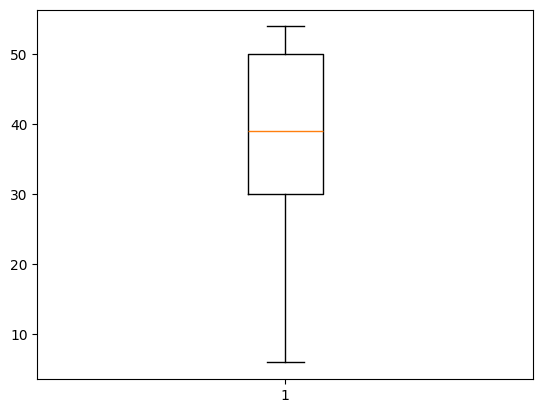

In [54]:
plt.boxplot(chats)

In [ ]:
# with open(f"../data/corrections/teflon/veb/als/corr_metrics.pkl", "rb") as f:
#     metrics = pickle.load(f)    

### EBS-ALS

In [107]:
c_grid = np.arange(1,54)
tau_grid = np.array([0.025,0.05,0.1,0.2,0.4])

for c, tau in itertools.product(c_grid, tau_grid):
    with open(f"../data/teflon/SO4/ebs/grid/ALS/c_{c}_tau_{tau}.pkl", "rb") as f:
        res = pickle.load(f)
        
    for i in res:
        a = i["absorbance"]
        id =  i["sample_id"]
        i["ref_corr"] = np.corrcoef(np.interp(gt[:,0],wn, a), gt[:,1])[0,1]
        i["load"] = loads.loc[id]["AS"]
       
    with open(f"../data/teflon/SO4/ebs/grid/ALS/c_{c}_tau_{tau}.pkl", "wb") as f:
        pickle.dump(res, f)
    

In [148]:
metrics_dict = []
for c, tau in itertools.product(c_grid, tau_grid):
    with open(f"../data/teflon/SO4/ebs/grid/ALS/c_{c}_tau_{tau}.pkl", "rb") as f:
        res = pickle.load(f)
    
    _,R2 = comp_simple_preds(res)
    
    metrics_dict.append({"c": c, "tau": tau, "mean_ref_corr": np.mean([i["ref_corr"] for i in res]), "se_ref_corr": np.std([i["ref_corr"] for i in res])/np.sqrt(len(res)), "R2": R2})

In [159]:
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv("../data/temp/metrics_df.csv", index=False)